<a href="https://colab.research.google.com/github/pandhana/Mini_Project01/blob/main/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#Import Libraries

import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.base import clone



# Download Dataset from Kaggle

path = kagglehub.dataset_download("sanlavisingh/healthcare-dataset-csv-32-13-kb")

print("Dataset downloaded to:", path)
print("Files inside folder:", os.listdir(path))

# โหลดไฟล์ CSV
df = pd.read_csv(os.path.join(path, "healthcare_dataset.csv"))

print("\n===== First 5 Rows =====")
print(df.head())

print("\n===== Data Info =====")
print(df.info())

print("\n===== Missing Values Before Cleaning =====")
print(df.isnull().sum())

Using Colab cache for faster access to the 'healthcare-dataset-csv-32-13-kb' dataset.
Dataset downloaded to: /kaggle/input/healthcare-dataset-csv-32-13-kb
Files inside folder: ['healthcare_dataset.csv', '.nfs00000000594b9f5f0000005e']

===== First 5 Rows =====
   Patient_ID  Age  Gender  Blood_Pressure  Heart_Rate  Cholesterol_Level  \
0           1   51  Female              97          90                282   
1           2   92   Other             129          80                169   
2           3   14    Male             172          76                157   
3           4   71  Female             131          82                150   
4           5   60    Male             130          96                206   

    BMI                Diagnosis Treatment_Plan Follow_Up_Date  
0  35.2             Hypertension    Observation     2024-01-01  
1  32.3                  Healthy     Medication     2024-01-02  
2  29.9                 Diabetes    Observation     2024-01-03  
3  19.4  Coronar

In [15]:
#Handling Missing Values

# เติม Age ด้วย Median
df['Age'] = df['Age'].fillna(df['Age'].median())

# เติมค่าตัวแปรเชิงตัวเลขตามกลุ่ม Diagnosis
cols_to_fix = ['Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'BMI']

for col in cols_to_fix:
    df[col] = df.groupby('Diagnosis')[col].transform(
        lambda x: x.fillna(x.median())
    )

# เติม Gender ด้วย Mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Treatment_Plan'] = df['Treatment_Plan'].fillna("None")


print("\n===== Missing Values After Filling =====")
print(df.isnull().sum())




===== Missing Values After Filling =====
Patient_ID           0
Age                  0
Gender               0
Blood_Pressure       0
Heart_Rate           0
Cholesterol_Level    0
BMI                  0
Diagnosis            0
Treatment_Plan       0
Follow_Up_Date       0
dtype: int64


In [16]:
df = df.drop(columns=['Patient_ID'], errors='ignore')
df = df.drop(columns=['Treatment_Plan'], errors='ignore')
df = df.drop(columns=['Follow_Up_Date'])

# 1 = Cardiovascular Disease
# 0 = Non-Cardiovascular

df['Cardio_Group'] = df['Diagnosis'].apply(
    lambda x: 1 if x in ['Coronary Artery Disease', 'Hypertension'] else 0
)

# ลบ Diagnosis เดิม
df = df.drop(columns=['Diagnosis'])

print("\n===== Class Distribution =====")
print(df['Cardio_Group'].value_counts())

df.head(6)



===== Class Distribution =====
Cardio_Group
0    298
1    202
Name: count, dtype: int64


,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Cardio_Group
0,51,Female,97,90,282,35.2,1
1,92,Other,129,80,169,32.3,0
2,14,Male,172,76,157,29.9,0
3,71,Female,131,82,150,19.4,1
4,60,Male,130,96,206,39.3,0
5,20,Male,95,75,213,35.7,0


In [17]:

# Remove Outliers using IQR


def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound

    return df

# Apply IQR to selected columns
df = remove_outliers_iqr(df, 'BMI')
df = remove_outliers_iqr(df, 'Cholesterol_Level')
df = remove_outliers_iqr(df, 'Blood_Pressure')
df = remove_outliers_iqr(df, 'Heart_Rate')

/tmp/ipykernel_949/389395664.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '64.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[column] < lower_bound, column] = lower_bound
/tmp/ipykernel_949/389395664.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '41.875' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[column] < lower_bound, column] = lower_bound


In [18]:
#After Cleaning
print("\n Data Summary After Cleaning ")
print(df.describe())

print("\n Final Missing Values")
print(df.isnull().sum())




 Data Summary After Cleaning 
             Age  Blood_Pressure  Heart_Rate  Cholesterol_Level         BMI  \
count  500.00000      500.000000  500.000000         500.000000  500.000000   
mean    48.87400      133.024000   79.874000         225.806000   29.430400   
std     29.56983       25.665246   11.354293          44.964608    6.132838   
min      0.00000       90.000000   60.000000         150.000000   18.600000   
25%     23.00000      112.000000   70.750000         186.000000   24.100000   
50%     50.00000      132.000000   79.500000         226.000000   29.600000   
75%     72.25000      154.000000   90.000000         267.000000   34.725000   
max     99.00000      179.000000   99.000000         299.000000   40.000000   

       Cardio_Group  
count    500.000000  
mean       0.404000  
std        0.491189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        1.000000  
max        1.000000  

 Final Missing Values
Age                  0
Gender       

Dataset Ready
Samples: 500
Total Features: 7

Baseline AUC (All Features): 0.5957

Using 2/3 Rule → Selecting top 5 features out of 7
Selected Features: ['Blood_Pressure', 'BMI', 'Cholesterol_Level', 'Age', 'Heart_Rate']
AUC after retraining (2/3 features): 0.5892

AUC-Based Permutation Importance Ranking
   rank            feature  auc_importance_mean  auc_importance_std
0     1     Blood_Pressure             0.062288            0.030227
1     2                BMI             0.030142            0.024249
2     3  Cholesterol_Level             0.007250            0.021094
3     4                Age            -0.006591            0.016503
4     5         Heart_Rate            -0.011866            0.017572


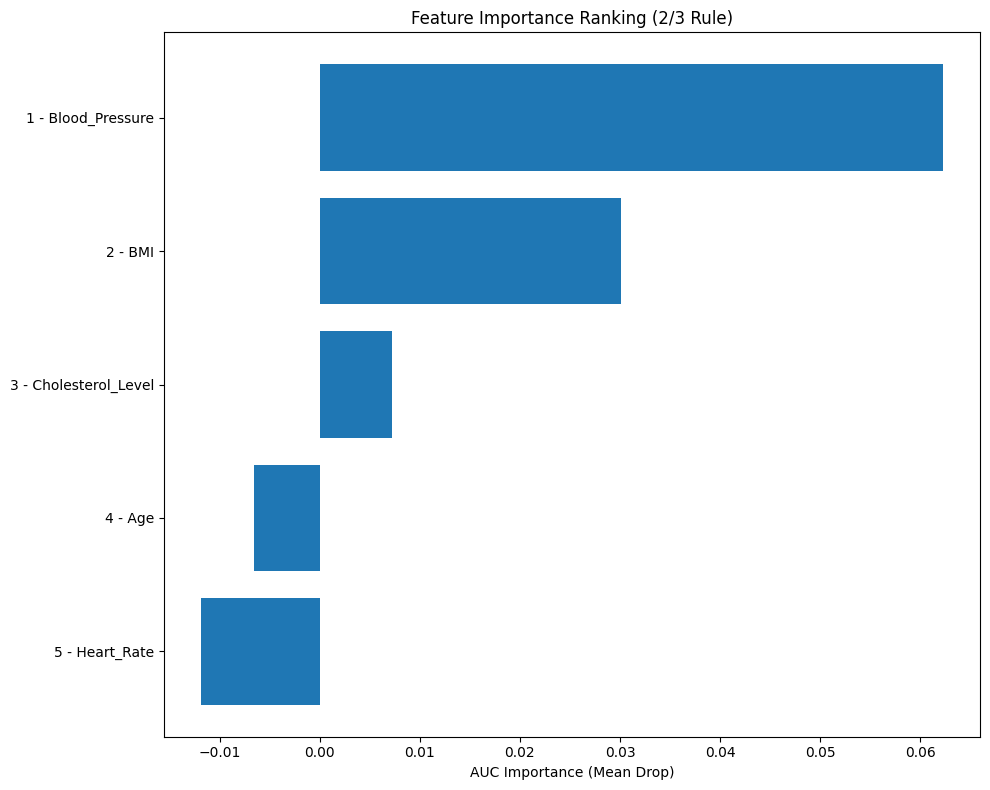


Pipeline Completed Successfully (2/3 Rule)


In [19]:
# Feature importance

# ============================================
# 1. Prepare Data (Your Dataset)
# ============================================

X = df.drop("Cardio_Group", axis=1)
y = df["Cardio_Group"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("======================================")
print("Dataset Ready")
print("Samples:", X.shape[0])
print("Total Features:", X.shape[1])
print("======================================")


# ============================================
# 2. Train / Validation Split
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# ============================================
# 3. Train Initial XGBoost Model
# ============================================

model_full = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model_full.fit(X_train, y_train)

baseline_auc = roc_auc_score(
    y_val,
    model_full.predict_proba(X_val)[:, 1]
)

print("\nBaseline AUC (All Features):", round(baseline_auc, 4))


# ============================================
# 4. Tree-based Ranking (GAIN)
# ============================================

booster = model_full.get_booster()
score_dict = booster.get_score(importance_type="gain")

tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": [score_dict.get(f, 0) for f in X.columns]
}).sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)


# ============================================
# 5. Dynamic 2/3 Feature Selection
# ============================================

total_features = X.shape[1]
k = int(np.ceil((2/3) * total_features))

selected_features = tree_importance.head(k)["feature"].tolist()

print(f"\nUsing 2/3 Rule → Selecting top {k} features out of {total_features}")
print("Selected Features:", selected_features)


# ============================================
# 6. Retrain Model with Selected Features
# ============================================

model_selected = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model_selected.fit(X_train[selected_features], y_train)

selected_auc = roc_auc_score(
    y_val,
    model_selected.predict_proba(X_val[selected_features])[:, 1]
)

print("AUC after retraining (2/3 features):", round(selected_auc, 4))


# ============================================
# 7. AUC-Based Permutation Importance
# ============================================

perm = permutation_importance(
    model_selected,
    X_val[selected_features],
    y_val,
    n_repeats=50,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": selected_features,
    "auc_importance_mean": perm.importances_mean,
    "auc_importance_std": perm.importances_std
}).sort_values(
    by="auc_importance_mean",
    ascending=False
).reset_index(drop=True)

importance_df["rank"] = importance_df.index + 1

importance_df = importance_df[[
    "rank",
    "feature",
    "auc_importance_mean",
    "auc_importance_std"
]]


# ============================================
# 8. Display Ranking
# ============================================

print("\n======================================")
print("AUC-Based Permutation Importance Ranking")
print("======================================")
print(importance_df)


# ============================================
# 9. Plot Importance
# ============================================

plt.figure(figsize=(10, 8))

labels = importance_df["rank"].astype(str) + " - " + importance_df["feature"]

plt.barh(labels, importance_df["auc_importance_mean"])

plt.xlabel("AUC Importance (Mean Drop)")
plt.title("Feature Importance Ranking (2/3 Rule)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nPipeline Completed Successfully (2/3 Rule)")


In [20]:
# ============================================
# 1. Prepare Data (Use Your Dataset)
# ============================================

X = df.drop("Cardio_Group", axis=1)
y = df["Cardio_Group"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("======================================")
print("Dataset Ready")
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("======================================\n")


# ============================================
# 2. Define Outer and Inner CV
# ============================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

outer_results = []
outer_best_k = []

min_k = 3   # ปรับตามจำนวน feature ของคุณ


# ============================================
# 3. Outer Loop
# ============================================

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):

    print(f"===== Outer Fold {fold_idx+1} =====")

    X_train_outer = X.iloc[train_idx]
    y_train_outer = y.iloc[train_idx]

    X_test_outer = X.iloc[test_idx]
    y_test_outer = y.iloc[test_idx]

    # Step A: Train model for feature importance
    model_full = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    model_full.fit(X_train_outer, y_train_outer)

    booster = model_full.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance_values = [
        score_dict.get(col, 0) for col in X.columns
    ]

    sorted_features = pd.DataFrame({
        "feature": X.columns,
        "importance": importance_values
    }).sort_values(
        by="importance",
        ascending=False
    )["feature"].tolist()


    # Step B: Inner CV to find best_k
    performance_records = []

    for k in range(min_k, len(sorted_features) + 1):

        selected_features = sorted_features[:k]
        fold_scores = []

        for inner_train_idx, inner_val_idx in inner_cv.split(
            X_train_outer, y_train_outer
        ):

            X_tr = X_train_outer.iloc[inner_train_idx][selected_features]
            y_tr = y_train_outer.iloc[inner_train_idx]

            X_va = X_train_outer.iloc[inner_val_idx][selected_features]
            y_va = y_train_outer.iloc[inner_val_idx]

            model = XGBClassifier(
                n_estimators=200,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )

            model.fit(X_tr, y_tr)
            preds = model.predict(X_va)

            fold_scores.append(accuracy_score(y_va, preds))

        mean_score = np.mean(fold_scores)
        performance_records.append((k, mean_score))


    performance_df = pd.DataFrame(
        performance_records,
        columns=["num_features", "cv_accuracy"]
    )

    best_k = performance_df.loc[
        performance_df["cv_accuracy"].idxmax(),
        "num_features"
    ]

    print("Best k from Inner CV:", best_k)
    outer_best_k.append(best_k)


    # Step C: Retrain with best_k
    best_features = sorted_features[:best_k]

    final_model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    final_model.fit(
        X_train_outer[best_features],
        y_train_outer
    )

    outer_preds = final_model.predict(
        X_test_outer[best_features]
    )

    outer_acc = accuracy_score(y_test_outer, outer_preds)

    print("Outer Fold Accuracy:", round(outer_acc, 4), "\n")

    outer_results.append(outer_acc)


# ============================================
# 4. Summary
# ============================================

outer_results = np.array(outer_results)
outer_best_k = np.array(outer_best_k)

print("======================================")
print("Nested CV Results")
print("======================================")

print("Outer Fold Accuracies:", np.round(outer_results, 4))
print("Mean Nested CV Accuracy:", round(np.mean(outer_results), 4))
print("Std Nested CV Accuracy:", round(np.std(outer_results), 4))

print("\nBest k chosen per fold:", outer_best_k.tolist())

print("\nMedian best k:", int(np.median(outer_best_k)))
print("Recommended number of features:", int(np.median(outer_best_k)))

print("\nNested CV Completed Successfully")

Dataset Ready
Samples: 500
Features: 7

===== Outer Fold 1 =====
Best k from Inner CV: 3
Outer Fold Accuracy: 0.6 

===== Outer Fold 2 =====
Best k from Inner CV: 3
Outer Fold Accuracy: 0.62 

===== Outer Fold 3 =====
Best k from Inner CV: 3
Outer Fold Accuracy: 0.51 

===== Outer Fold 4 =====
Best k from Inner CV: 3
Outer Fold Accuracy: 0.63 

===== Outer Fold 5 =====
Best k from Inner CV: 3
Outer Fold Accuracy: 0.55 

Nested CV Results
Outer Fold Accuracies: [0.6  0.62 0.51 0.63 0.55]
Mean Nested CV Accuracy: 0.582
Std Nested CV Accuracy: 0.0453

Best k chosen per fold: [3, 3, 3, 3, 3]

Median best k: 3
Recommended number of features: 3

Nested CV Completed Successfully


In [21]:
print("\n===== Selected Features =====")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

removed_features = list(set(X.columns) - set(selected_features))



===== Selected Features =====
1. Age
2. BMI
3. Cholesterol_Level
4. Blood_Pressure
5. Gender_Other
6. Heart_Rate
7. Gender_Male



===== Cross Validation Results =====

kNN
Mean CV AUC: 0.4212
Std CV AUC : 0.0471

Neural Network
Mean CV AUC: 0.482
Std CV AUC : 0.0461

XGBoost
Mean CV AUC: 0.503
Std CV AUC : 0.0264

===== Validation Set Results =====
                Accuracy       AUC  Sensitivity  Specificity
Neural Network  0.593333  0.579849     0.000000     1.000000
XGBoost         0.573333  0.575060     0.442623     0.662921
kNN             0.573333  0.516946     0.311475     0.752809


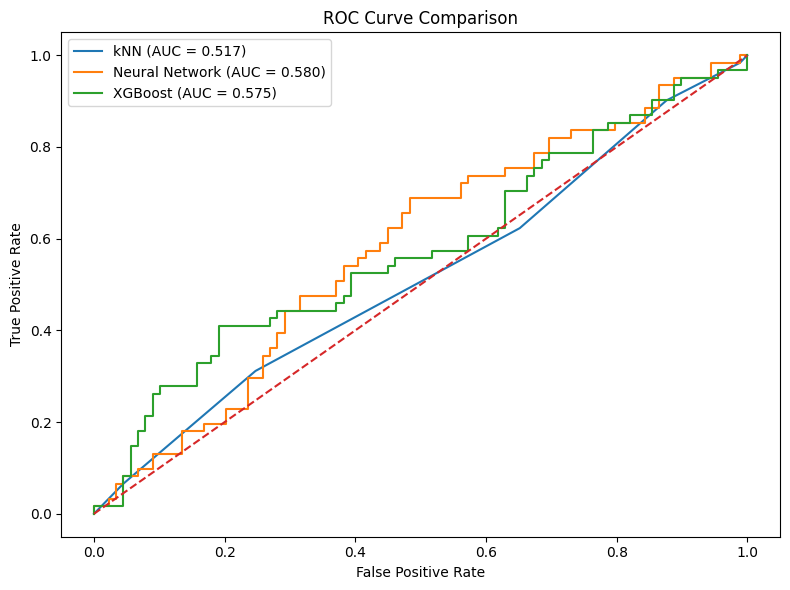


Pipeline Completed Successfully


In [24]:
# TRAIN / VALIDATION SPLIT
X = df.drop("Cardio_Group", axis=1)
y = df["Cardio_Group"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


# HANDLE CLASS IMBALANCE
class_counts = y_train.value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]


# DEFINE MODELS


knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7))
])

nn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=2000,
        learning_rate_init=0.001,
        early_stopping=True,
        random_state=42
    ))
])

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

models = {
    "kNN": knn_model,
    "Neural Network": nn_model,
    "XGBoost": xgb_model
}



# 5-FOLD CROSS VALIDATION (AUC)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, base_model in models.items():
    fold_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx].copy()
        X_val_fold = X_train.iloc[val_idx].copy()
        y_tr = y_train.iloc[train_idx].copy()
        y_val_fold = y_train.iloc[val_idx].copy()

        model = clone(base_model)

        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_val_fold)[:, 1]

        auc = roc_auc_score(y_val_fold, y_prob)
        fold_scores.append(auc)

    cv_results[name] = {
        "Mean CV AUC": np.mean(fold_scores),
        "Std CV AUC": np.std(fold_scores)
    }

print("\n===== Cross Validation Results =====")
for model_name, metrics in cv_results.items():
    print(f"\n{model_name}")
    print("Mean CV AUC:", round(metrics["Mean CV AUC"], 4))
    print("Std CV AUC :", round(metrics["Std CV AUC"], 4))


# FINAL TRAINING + VALIDATION EVALUATION
test_results = {}

for name, base_model in models.items():

    model = clone(base_model)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)

    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    test_results[name] = {
        "Accuracy": acc,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }

results_df = pd.DataFrame(test_results).T
results_df = results_df.sort_values(by="AUC", ascending=False)

print("\n===== Validation Set Results =====")
print(results_df)


plt.figure(figsize=(8, 6))

for name, base_model in models.items():

    model = clone(base_model)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

print("\nPipeline Completed Successfully")

In [23]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("\n===== kNN Best Parameters =====")
print(knn_grid.best_params_)
print("Best CV AUC:", round(knn_grid.best_score_, 4))


nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=2000, random_state=42))
])

nn_param_grid = {
    'mlp__hidden_layer_sizes': [(64,), (64,32), (128,64)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01]
}

nn_grid = GridSearchCV(
    nn_pipeline,
    nn_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

nn_grid.fit(X_train, y_train)

print("\n===== Neural Network Best Parameters =====")
print(nn_grid.best_params_)
print("Best CV AUC:", round(nn_grid.best_score_, 4))


xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ),
    xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("\n===== XGBoost Best Parameters =====")
print(xgb_grid.best_params_)
print("Best CV AUC:", round(xgb_grid.best_score_, 4))




best_results = {
    "kNN": knn_grid.best_score_,
    "Neural Network": nn_grid.best_score_,
    "XGBoost": xgb_grid.best_score_
}

print("\n===== Best CV Comparison =====")
for model, score in best_results.items():
    print(model, ":", round(score, 4))

best_model_name = max(best_results, key=best_results.get)
print("\nBest Model from Grid Search:", best_model_name)


===== kNN Best Parameters =====
{'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Best CV AUC: 0.4182

===== Neural Network Best Parameters =====
{'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.01}
Best CV AUC: 0.4568

===== XGBoost Best Parameters =====
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best CV AUC: 0.4899

===== Best CV Comparison =====
kNN : 0.4182
Neural Network : 0.4568
XGBoost : 0.4899

Best Model from Grid Search: XGBoost
